In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from importlib.resources import Path
from pathlib import Path
from sklearn.model_selection import train_test_split


In [2]:
def get_image_paths(base_path, split="train", class_name="NORMAL"):
    """Retorna os caminhos de todas as imagens em um diretório específico."""
    img_dir = os.path.join(base_path, split, class_name)
    image_names = os.listdir(img_dir)
    return [os.path.join(img_dir, name) for name in image_names]

def load_image(image_path):
    """Carrega uma imagem usando OpenCV e a converte para o formato RGB."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Não foi possível carregar a imagem em {image_path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def preprocess_image(img, target_size=(224, 224)):
    """Redimensiona e normaliza a imagem."""
    img_resized = cv2.resize(img, target_size)
    img_normalized = img_resized / 255.0
    return img_normalized

def show_image(img, title="Imagem"):
    """Função utilitária para exibir a imagem com matplotlib."""
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

Total de imagens encontradas: 1341
Exemplo de caminho: dataset/archive/chest_xray\train\NORMAL\IM-0115-0001.jpeg
Shape original: (1858, 2090, 3)


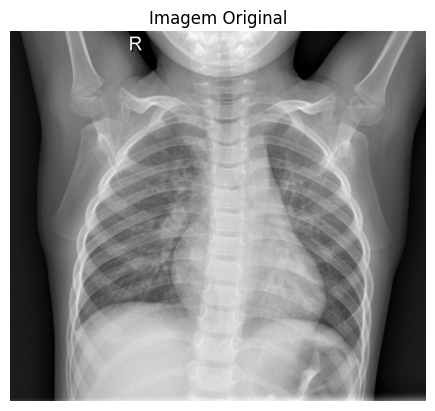

Shape após redimensionamento: (224, 224, 3)


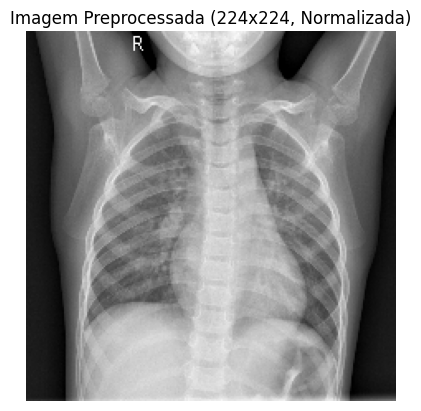

In [3]:
# Definir o caminho base do dataset
BASE_PATH = "dataset/archive/chest_xray"

# Obter caminhos das imagens
normal_train_paths = get_image_paths(BASE_PATH, split="train", class_name="NORMAL")
print(f"Total de imagens encontradas: {len(normal_train_paths)}")
print(f"Exemplo de caminho: {normal_train_paths[0]}")

# Carregar e visualizar a primeira imagem
first_image_path = normal_train_paths[0]
img_rgb = load_image(first_image_path)
print(f"Shape original: {img_rgb.shape}")
show_image(img_rgb, title="Imagem Original")

# Preprocessar e visualizar
img_preprocessed = preprocess_image(img_rgb, target_size=(224, 224))
print(f"Shape após redimensionamento: {img_preprocessed.shape}")
show_image(img_preprocessed, title="Imagem Preprocessada (224x224, Normalizada)")

In [7]:
# -- CONFIG DOS NOVOS DIRETORIOS --     
# Onde os dados processados serão salvos de forma organizada
DATASET_FINAL = Path('dataset_processado')
CLASSES = ['NORMAL', 'PNEUMONIA']
DIVISOES = ['train', 'val', 'test']

# Cria a estrutura de pasta local (se não existir)
for divisao in DIVISOES:
    for classe in CLASSES:
        (DATASET_FINAL / divisao / classe).mkdir(parents=True, exist_ok=True)

print('Estrutura de pastas para o dataset final criada com sucesso!')

# -- LOOP POR CLASSE PARA UNIFICAR E RE-DIVIDIR
for classe in CLASSES:
    print(f'\nColetando imagens da classe: {classe}')

    # Unifica os caminhos buscando dentro de train, val e test originais do Kaggle
    todos_os_caminhos = []
    for split in ['train', 'val', 'test']:
        # CORREÇÃO: Ajustado o nome do parâmetro para 'split' e a variável para 'split'
        caminhos = get_image_paths(BASE_PATH, split=split, class_name=classe)
        todos_os_caminhos.extend(caminhos)

    # CORREÇÃO: Joguei o print para fora do loop 'for split' para mostrar o total consolidado
    print(f'Total de imagens combinadas para {classe}: {len(todos_os_caminhos)}')

    # Split Estatístico Robusto (70% Treino, 15% Validação, 15% Teste)
    # Primeiro corte: Separa 70% para treino e deixa 30% para o resto
    treino_paths, resto_paths = train_test_split(todos_os_caminhos, test_size=0.30, random_state=42)
    # Segundo corte: Divide os 30% restantes no meio (15% para validação e 15% para teste)
    val_paths, teste_paths = train_test_split(resto_paths, test_size=0.50, random_state=42)
    
    # Mapeamento para o loop de salvamento
    mapeamento_split = {
        'train': treino_paths,
        'val': val_paths,
        'test': teste_paths
    }
    
    # --- 3. PROCESSAMENTO E SALVAMENTO FÍSICO ---
    for divisao, lista_caminhos in mapeamento_split.items():
        print(f" -> Processando e salvando {len(lista_caminhos)} imagens em '{divisao}'...")
        
        for idx, caminho_origem in enumerate(lista_caminhos):
            try:
                # Usa as suas funções validadas!
                img = load_image(caminho_origem)
                img_tratada = preprocess_image(img, target_size=(224, 224))
                
                # Define o nome padronizado e o caminho final do arquivo
                nome_arquivo = f"{classe.lower()}_{divisao}_{idx}.png"
                caminho_destino = DATASET_FINAL / divisao / classe / nome_arquivo
                
                # Salva a imagem tratada em disco
                cv2.imwrite(str(caminho_destino), img_tratada)
                
            except Exception as e:
                print(f"Erro ao processar a imagem {caminho_origem}: {e}")

print("\n[SUCESSO] Todo o dataset foi processado, normalizado e salvo em './dataset_processado'!")

Estrutura de pastas para o dataset final criada com sucesso!

Coletando imagens da classe: NORMAL
Total de imagens combinadas para NORMAL: 1583
 -> Processando e salvando 1108 imagens em 'train'...
 -> Processando e salvando 237 imagens em 'val'...
 -> Processando e salvando 238 imagens em 'test'...

Coletando imagens da classe: PNEUMONIA
Total de imagens combinadas para PNEUMONIA: 4273
 -> Processando e salvando 2991 imagens em 'train'...
 -> Processando e salvando 641 imagens em 'val'...
 -> Processando e salvando 641 imagens em 'test'...

[SUCESSO] Todo o dataset foi processado, normalizado e salvo em './dataset_processado'!
